## Florida Wildlife Observation Analysis and Prediction
### Using citizen science data for a machine learning task

The goal of this project was to understand the distribution of three wildlife species using observation data and employ machine learning to predict which species is most likely to be observed based on geographic and temporal information.

The dataset consisted of observation records obtained from iNaturalist, a community wildlife observation platform that provides standardized citizen science data, containing species identifications, observation dates, and geographic coordinates for American Crocodiles, Burmese Pythons, and Argentine Black-and-white Tegus in Florida.

Observation and species records were stored in a relational MySQL database and retrieved using SQL queries before being imported into Python for exploratory data analysis and machine learning.

Exploratory data analysis was conducted to uncover spatiotemporal patterns in species observations, including geographic distribution, seasonal trends, and changes in observation frequency over time.

Several machine learning classification models were evaluated, including Logistic Regression, Decision Tree, and Random Forest classifiers, to determine the most effective approach for predicting species observations.

The final Random Forest model achieved the highest macro F1-score, indicating the strongest overall performance across all three species classes.

## Project Objectives 
* Build and query a relational MySQL database containing wildlife observation records and species information.
* Perform exploratory data analysis to identify spatiotemporal patterns, geographic distributions, and seasonal trends among American Crocodiles, Burmese Pythons, and Argentine Black-and-white Tegus.
* Engineer predictive features from geographic and temporal observation data, including location, observation date, and seasonal variables.
* Develop and evaluate multiple machine learning classification models capable of predicting species observations based on geographic and temporal information.
* Compare model performance using accuracy, macro F1-score, confusion matrices, and feature importance analysis to identify the most effective predictive model.
* Investigate the impact of additional ecological features, such as Florida wet and dry seasons, on model performance.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Data Extraction and Preparation

In [ ]:
# Connect to MySQL database

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="YOUR_PASSWORD",
    database="wildlife"
)

print("Connected!")

Connected!


In [3]:
# Load species table

query = """
SELECT *
FROM species;
"""

df_species = pd.read_sql(query, conn)

df_species

C:\Users\joeyc\AppData\Local\Temp\ipykernel_17964\3924921115.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_species = pd.read_sql(query, conn)


,species_id,common_name,scientific_name
0,1,American Crocodile,Crocodylus acutus
1,2,Burmese Python,Python bivittatus
2,3,Argentine Black-and-white Tegu,Salvator merianae


In [4]:
# Load wildlife observations

query = """
SELECT
    s.common_name,
    o.observed_on,
    o.latitude,
    o.longitude,
    o.place_county_name,
    o.place_state_name
FROM observations o
JOIN species s
    ON o.species_id = s.species_id;
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\joeyc\AppData\Local\Temp\ipykernel_17964\3450896775.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,common_name,observed_on,latitude,longitude,place_county_name,place_state_name
0,American Crocodile,2009-05-14,25.177188,-80.922653,Monroe,Florida
1,American Crocodile,2011-01-30,25.118210,-80.944906,Monroe,Florida
2,American Crocodile,2008-02-14,25.031770,-80.986856,Monroe,Florida
3,American Crocodile,2008-04-08,25.052260,-80.855483,Monroe,Florida
4,American Crocodile,2008-04-08,25.163806,-80.825625,Monroe,Florida


In [5]:
# Dataset overview

df.shape

(4757, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4757 entries, 0 to 4756
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   common_name        4757 non-null   object 
 1   observed_on        4757 non-null   object 
 2   latitude           4757 non-null   float64
 3   longitude          4757 non-null   float64
 4   place_county_name  4757 non-null   object 
 5   place_state_name   4757 non-null   object 
dtypes: float64(2), object(4)
memory usage: 223.1+ KB


In [7]:
# Display all unique species
df['common_name'].unique()

array(['American Crocodile', 'Burmese Python',
       'Argentine Black-and-white Tegu'], dtype=object)

## Exploratory Data Analysis

In [8]:
# Count observations for each species in the dataset
df['common_name'].value_counts()

common_name
American Crocodile                3840
Burmese Python                     677
Argentine Black-and-white Tegu     240
Name: count, dtype: int64

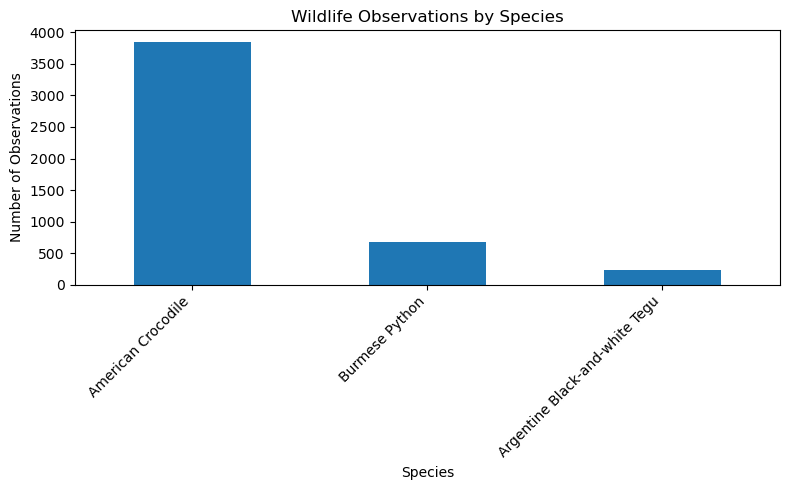

In [9]:
# Visualize the number of observations for each species

species_counts = df['common_name'].value_counts()

plt.figure(figsize=(8, 5))
species_counts.plot(kind='bar')

plt.title('Wildlife Observations by Species')
plt.xlabel('Species')
plt.ylabel('Number of Observations')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

American Crocodiles account for the vast majority of observations (3,840), while Burmese Pythons (677) and Argentine Black-and-white Tegus (240) represent a much smaller share of the dataset

In [10]:
# Convert observation date to datetime format
df['observed_on'] = pd.to_datetime(df['observed_on'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4757 entries, 0 to 4756
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   common_name        4757 non-null   object        
 1   observed_on        4757 non-null   datetime64[ns]
 2   latitude           4757 non-null   float64       
 3   longitude          4757 non-null   float64       
 4   place_county_name  4757 non-null   object        
 5   place_state_name   4757 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 223.1+ KB


In [12]:
# Check for missing values
df.isnull().sum()

common_name          0
observed_on          0
latitude             0
longitude            0
place_county_name    0
place_state_name     0
dtype: int64

In [13]:
# Determine the earliest and latest observation dates
print("Earliest observation:", df['observed_on'].min())
print("Latest observation:", df['observed_on'].max())

Earliest observation: 1986-12-18 00:00:00
Latest observation: 2026-06-03 00:00:00


The dataset covers about 40 years of observations (1986-2026).

In [14]:
# Extract the observation year
df['year'] = df['observed_on'].dt.year

In [15]:
# Count observations by year
yearly_observations = df['year'].value_counts().sort_index()

# sort_index() sorts the index by year in ascending order, ensuring that the observations are displayed chronologically.

# View observations by year
yearly_observations

year
1986      1
1999      1
2000      1
2001      2
2002      1
2003      2
2004      5
2005     12
2006     11
2007     14
2008     26
2009     31
2010     16
2011     22
2012     38
2013     50
2014     46
2015     68
2016     92
2017    130
2018    222
2019    292
2020    324
2021    436
2022    435
2023    485
2024    684
2025    815
2026    495
Name: count, dtype: int64

Wildlife observations increased over time, with the highest counts occurring in recent years. The 2026 total is lower because it only includes part of the year.

In [16]:
# Observations by species and year
species_by_year = pd.crosstab(df['year'], df['common_name'])

# crosstab() creates a contingency table that counts the occurrences of each species for each year, allowing us to analyze trends in wildlife observations over time.
species_by_year

common_name,American Crocodile,Argentine Black-and-white Tegu,Burmese Python
year,,,
1986,1,0,0
1999,1,0,0
2000,1,0,0
2001,2,0,0
2002,1,0,0
2003,2,0,0
2004,4,0,1
2005,12,0,0
2006,9,0,2


Observations for all three species generally increased over time, but American Crocodiles account for most sightings and drive the overall upward trend. This class imbalance was later considered during model evaluation.

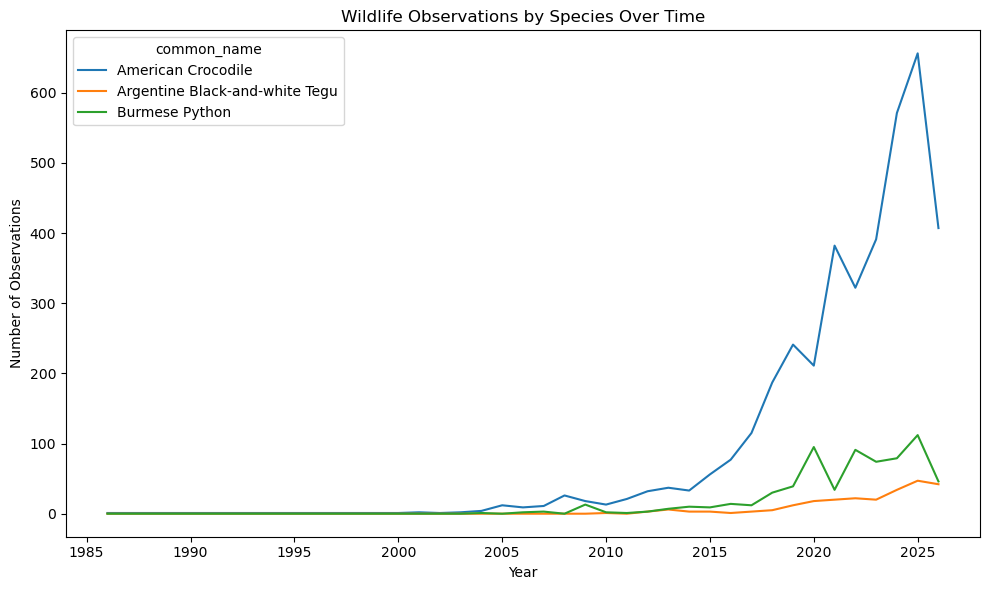

In [17]:
# Plot yearly observations by species

plt.figure(figsize=(10, 6))

species_by_year.plot(ax=plt.gca())

plt.title('Wildlife Observations by Species Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Observations')

plt.tight_layout()
plt.show()

This visualization shows how observations of each species changed over time. American Crocodiles had the highest number of observations throughout the dataset and experienced the most substantial increase in recent years. Burmese Python observations also increased over time, while Argentine Black-and-white Tegu observations remained much lower overall.

All three species show an upward trend in observations, particularly after 2015. This could indicate increased species activity, increased reporting effort, growth in iNaturalist usage, or a combination of these factors. The differing trends suggest that time may be a useful feature for predicting which species is likely to be observed.

In [18]:
# Make a dataframe of the latitude and longitude columns and display summary statistics for both columns
df[['latitude', 'longitude']].describe()

,latitude,longitude
count,4757.000000,4757.000000
mean,25.421420,-80.744645
std,0.543086,0.401484
min,24.401461,-83.169603
25%,25.107633,-80.924541
50%,25.249321,-80.820786
75%,25.648658,-80.435831
max,30.385344,-80.002096


Summary statistics for latitude and longitude were examined to understand the geographic spread of observations and identify potential outliers before creating spatial visualizations. The coordinate ranges were consistent with expected locations in South Florida and did not reveal any obvious data quality concerns.

In [19]:
# Count unique counties
df['place_county_name'].nunique()

26

In [20]:
# Top 10 counties by observation count
df['place_county_name'].value_counts().head(10)

place_county_name
Monroe          2492
Miami-Dade      1895
Collier          155
Broward           51
Hillsborough      46
Palm Beach        32
Lee               21
Alachua           14
Pinellas           8
Orange             7
Name: count, dtype: int64

Most observations are concentrated in Monroe and Miami-Dade counties, which together account for over 90% of the dataset.

In [21]:
# Species observations by county
county_species = pd.crosstab(
    df['place_county_name'],
    df['common_name']
)

county_species

common_name,American Crocodile,Argentine Black-and-white Tegu,Burmese Python
place_county_name,,,
Alachua,13,1,0
Brevard,4,0,0
Broward,7,2,42
Charlotte,0,4,0
Collier,44,2,109
Duval,0,1,0
Glades,0,0,1
Hendry,0,0,4
Highlands,1,0,0


In [22]:
# Average latitude and longitude by species
# Use groupby to split data into groups, apply a calculation to each group, and combine the results into a DataFrame.
df.groupby('common_name')[['latitude', 'longitude']].mean()

,latitude,longitude
common_name,,
American Crocodile,25.365895,-80.756733
Argentine Black-and-white Tegu,25.791704,-80.588839
Burmese Python,25.605092,-80.731310


In [23]:
df.groupby('common_name')[['latitude', 'longitude']].describe()

latitude                                  \
                                  count       mean       std        min   
common_name                                                               
American Crocodile               3840.0  25.365895  0.514301  24.401461   
Argentine Black-and-white Tegu    240.0  25.791704  0.937211  25.223397   
Burmese Python                    677.0  25.605092  0.403011  25.051999   

                                                                            \
                                      25%        50%        75%        max   
common_name                                                                  
American Crocodile              25.085395  25.175007  25.625186  29.717695   
Argentine Black-and-white Tegu  25.403727  25.447056  25.470836  30.358224   
Burmese Python                  25.293696  25.497604  25.851038  30.385344   

                               longitude                                  \
                                   count       mean       std        min   
common_name                                                                
American Crocodile                3840.0 -80.756733  0.404517 -82.988600   
Argentine Black-and-white Tegu     240.0 -80.588839  0.382422 -82.626398   
Burmese Python                     677.0 -80.731310  0.378736 -83.169603   

                                                                            
                                      25%        50%        75%        max  
common_name                                                                 
American Crocodile             -80.930752 -80.841594 -80.398152 -80.002096  
Argentine Black-and-white Tegu -80.526402 -80.501812 -80.452667 -80.173012  
Burmese Python                 -80.898650 -80.678398 -80.438146 -80.133806

A boolean mask was used to plot one species at a time. This made it easier to compare where each species was observed rather than displaying all observations as a single group.

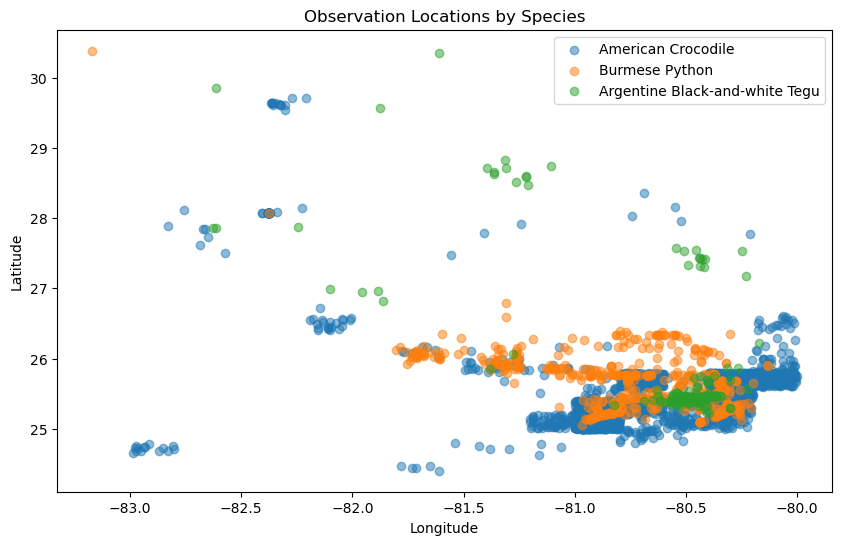

In [24]:
# Plot observation locations by species
# The subset condition creates a Boolean mask to keep only matching rows for the current species, allowing us to plot the locations of observations for each species separately.
plt.figure(figsize=(10, 6))

for species in df['common_name'].unique():
    subset = df[df['common_name'] == species]

    plt.scatter(
        subset['longitude'],
        subset['latitude'],
        label=species,
        alpha=0.5
    )

plt.title('Observation Locations by Species')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

plt.show()

Species locations overlap, but each species shows distinct geographic patterns. This suggests latitude and longitude may be useful features for predicting species observations.
The orange points (pythons) appear concentrated in a narrower band.
The blue points (crocodiles) are much more widespread.
The green points (tegus) seem to have several clusters.

In [25]:
# Extract observation month
df['month'] = df['observed_on'].dt.month

# Extract abbreviated month name
df['month_name'] = df['observed_on'].dt.strftime('%b')

In [26]:
# Count observations by month
monthly_observations = (
    df.groupby(['month', 'month_name'])
      .size()
      .reset_index(name='count')
)

monthly_observations

,month,month_name,count
0,1,Jan,559
1,2,Feb,483
2,3,Mar,748
3,4,Apr,479
4,5,May,306
5,6,Jun,311
6,7,Jul,306
7,8,Aug,227
8,9,Sep,132
9,10,Oct,162


Observations are not evenly distributed throughout the year. Observation counts are highest in March and lowest in September and October, suggesting a seasonal pattern in wildlife observations.

In [27]:
species_by_month = pd.crosstab(
    df['month_name'],
    df['common_name']
)

month_order = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

species_by_month = species_by_month.reindex(month_order)

species_by_month

common_name,American Crocodile,Argentine Black-and-white Tegu,Burmese Python
month_name,,,
Jan,513,4,42
Feb,440,10,33
Mar,672,44,32
Apr,399,51,29
May,222,39,45
Jun,237,29,45
Jul,142,19,145
Aug,123,22,82
Sep,83,12,37


reindex() was used to arrange months in chronological order so seasonal trends could be visualized correctly.

Different species show distinct seasonal observation patterns. Crocodile observations peak during winter and early spring, python observations peak during summer, and tegu observations are most common in spring. This suggests month may be a useful predictive feature.

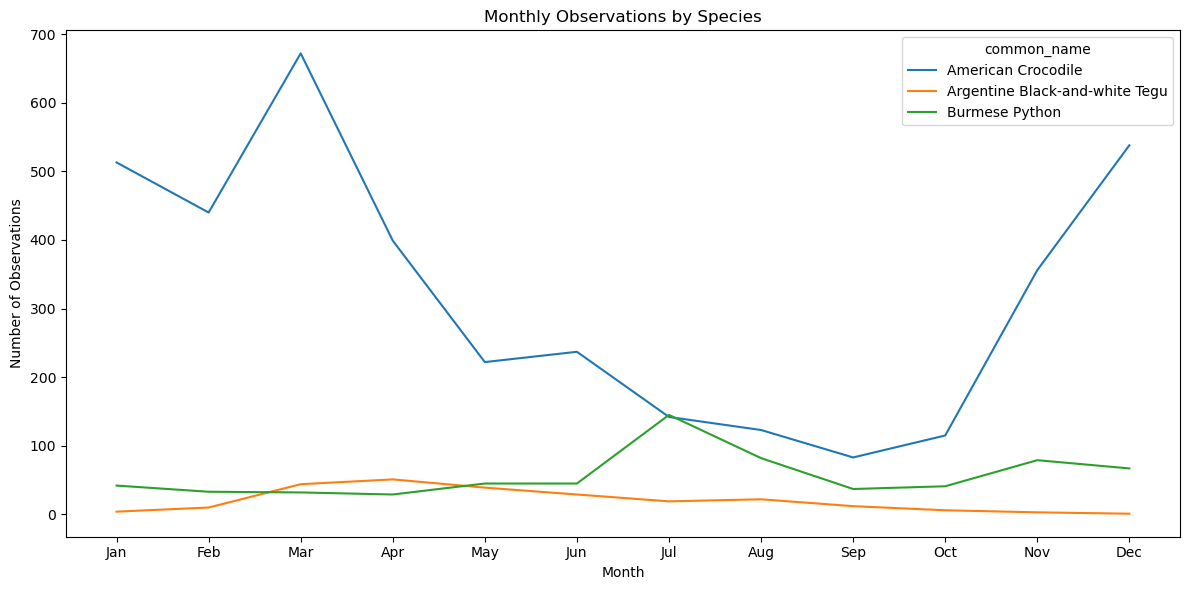

In [28]:
# Plot monthly observations by species

species_by_month.plot(figsize=(12, 6))

plt.title('Monthly Observations by Species')
plt.xlabel('Month')
plt.ylabel('Number of Observations')

plt.xticks(
    ticks=range(len(species_by_month.index)),
    labels=species_by_month.index
)

plt.tight_layout()
plt.show()

American Crocodile observations show the strongest seasonal pattern, peaking between December and March and reaching their lowest levels between August and October. Burmese Python observations peak in July, while Argentine Black-and-white Tegu observations are highest during spring (March-May). These differences suggest that month may be a useful feature for predicting species observations.

In [29]:
fig = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color='common_name',
    title='Wildlife Observation Locations'
)

fig.update_geos(
    fitbounds='locations'
)

fig.update_layout(
    width=900,
    height=500,
    title_x=0.5,
    legend=dict(
        x=0.85,
        y=0.95
    )
)

fig.show()

Wildlife observations are concentrated in South Florida, particularly around Miami-Dade and Monroe counties. The map reveals that observations are not randomly distributed across the study area, but instead tend to cluster in distinct geographic regions. American Crocodiles appear across the widest geographic range, while Burmese Pythons and Argentine Black-and-white Tegus are more spatially concentrated. These geographic differences suggest that location may be a strong predictor of species identity and help explain why latitude and longitude later emerged as the most important features in the machine learning models.

In [30]:
# Review model features
df.head()

,common_name,observed_on,latitude,longitude,place_county_name,place_state_name,year,month,month_name
0,American Crocodile,2009-05-14,25.177188,-80.922653,Monroe,Florida,2009,5,May
1,American Crocodile,2011-01-30,25.118210,-80.944906,Monroe,Florida,2011,1,Jan
2,American Crocodile,2008-02-14,25.031770,-80.986856,Monroe,Florida,2008,2,Feb
3,American Crocodile,2008-04-08,25.052260,-80.855483,Monroe,Florida,2008,4,Apr
4,American Crocodile,2008-04-08,25.163806,-80.825625,Monroe,Florida,2008,4,Apr


In [31]:
df['common_name'].value_counts(normalize=True) * 100

common_name
American Crocodile                80.723145
Burmese Python                    14.231659
Argentine Black-and-white Tegu     5.045197
Name: proportion, dtype: float64

The dataset is highly imbalanced, with American Crocodiles representing over 80% of all observations. This imbalance should be considered during model evaluation because a model could achieve high accuracy by predicting the majority class alone.

## Model Development

In [32]:
# Select model features and target
model_df = df[
    [
        'latitude',
        'longitude',
        'place_county_name',
        'year',
        'month',
        'common_name'
    ]
].copy()

model_df.head()

,latitude,longitude,place_county_name,year,month,common_name
0,25.177188,-80.922653,Monroe,2009,5,American Crocodile
1,25.118210,-80.944906,Monroe,2011,1,American Crocodile
2,25.031770,-80.986856,Monroe,2008,2,American Crocodile
3,25.052260,-80.855483,Monroe,2008,4,American Crocodile
4,25.163806,-80.825625,Monroe,2008,4,American Crocodile


A copy of the modeling dataset was created to isolate the variables needed for machine learning and avoid potential issues when modifying a slice of the original DataFrame.

In [33]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4757 entries, 0 to 4756
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   latitude           4757 non-null   float64
 1   longitude          4757 non-null   float64
 2   place_county_name  4757 non-null   object 
 3   year               4757 non-null   int32  
 4   month              4757 non-null   int32  
 5   common_name        4757 non-null   object 
dtypes: float64(2), int32(2), object(2)
memory usage: 185.9+ KB


In [34]:
model_df['place_county_name'].nunique()

26

In [35]:
model_df['place_county_name'].unique()

array(['Monroe', 'Miami-Dade', 'Alachua', 'Hillsborough', 'Pinellas',
       'Collier', 'Lee', 'Highlands', 'Osceola', 'Broward', 'Brevard',
       'Palm Beach', 'Manatee', 'Indian River', 'Polk', 'Glades',
       'Hendry', 'Suwannee', 'Seminole', 'Charlotte', 'Putnam', 'Martin',
       'Saint Lucie', 'Orange', 'St. Lucie', 'Duval'], dtype=object)

In [36]:
# Standardize county names to remove duplicate categories

model_df['place_county_name'] = model_df['place_county_name'].replace({
    'Saint Lucie': 'St. Lucie'
})

In [37]:
model_df['place_county_name'].value_counts()

place_county_name
Monroe          2492
Miami-Dade      1895
Collier          155
Broward           51
Hillsborough      46
Palm Beach        32
Lee               21
Alachua           14
St. Lucie         11
Pinellas           8
Orange             7
Brevard            4
Charlotte          4
Hendry             4
Seminole           3
Martin             1
Putnam             1
Manatee            1
Suwannee           1
Glades             1
Polk               1
Indian River       1
Osceola            1
Highlands          1
Duval              1
Name: count, dtype: int64

In [38]:
# Define features and target

X = model_df[
    [
        'latitude',
        'longitude',
        'place_county_name',
        'year',
        'month'
    ]
]

y = model_df['common_name']

The target variable (y) was the observed species (common_name), while the feature set (X) contained geographic and temporal variables used to predict species identity.

In [39]:
X.head()

,latitude,longitude,place_county_name,year,month
0,25.177188,-80.922653,Monroe,2009,5
1,25.118210,-80.944906,Monroe,2011,1
2,25.031770,-80.986856,Monroe,2008,2
3,25.052260,-80.855483,Monroe,2008,4
4,25.163806,-80.825625,Monroe,2008,4


In [40]:
y.head()

0    American Crocodile
1    American Crocodile
2    American Crocodile
3    American Crocodile
4    American Crocodile
Name: common_name, dtype: object

In [41]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Twenty percent of the observations were reserved for testing, while the remaining data was used for training. Stratification preserved the species distribution in both datasets, ensuring that model performance was evaluated on representative samples of each class.


In [42]:
X_train.shape

(3805, 5)

In [43]:
X_test.shape

(952, 5)

In [44]:
X_train['place_county_name'].nunique()

24

In [45]:
sorted(X_train['place_county_name'].unique())

['Alachua',
 'Brevard',
 'Broward',
 'Charlotte',
 'Collier',
 'Duval',
 'Glades',
 'Hendry',
 'Highlands',
 'Hillsborough',
 'Indian River',
 'Lee',
 'Manatee',
 'Martin',
 'Miami-Dade',
 'Monroe',
 'Orange',
 'Palm Beach',
 'Pinellas',
 'Polk',
 'Putnam',
 'Seminole',
 'St. Lucie',
 'Suwannee']

County names were encoded because the model requires numerical inputs and cannot learn directly from text categories. One-hot encoding was applied using pd.get_dummies(), creating a separate binary column for each county.

In [46]:
# One-hot encode county names

X_train_encoded = pd.get_dummies(
    X_train,
    columns=['place_county_name']
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=['place_county_name']
)

In [47]:
# Align test set columns with training set

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

The test dataset was aligned with the training dataset to ensure both contained the same feature columns after one-hot encoding. Missing columns were filled with zeros so the model could process the test data correctly.

In [48]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(3805, 28)
(952, 28)


One-hot encoding increased the number of features by replacing the single county column with multiple binary county indicators. This allowed the model to use county information without introducing an artificial numerical relationship between counties.

In [49]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    random_state=42
)

Random Forest combines predictions from many decision trees. Each tree is trained on a different subset of observations and features. The final prediction is determined by aggregating predictions across all trees, helping reduce the impact of overfitting from any individual tree.

In [50]:
# Train model

rf_model.fit(
    X_train_encoded,
    y_train
)

RandomForestClassifier(random_state=42)

In [51]:
# Predict species on test data

y_pred = rf_model.predict(
    X_test_encoded
)

In [52]:
y_pred[:10]

array(['Burmese Python', 'American Crocodile', 'American Crocodile',
       'American Crocodile', 'American Crocodile', 'American Crocodile',
       'American Crocodile', 'American Crocodile', 'Burmese Python',
       'American Crocodile'], dtype=object)

## Model Evaluation

In [53]:
# Calculate model accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.9275210084033614


In [54]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                                precision    recall  f1-score   support

            American Crocodile       0.95      0.98      0.96       768
Argentine Black-and-white Tegu       0.86      0.77      0.81        48
                Burmese Python       0.81      0.71      0.75       136

                      accuracy                           0.93       952
                     macro avg       0.87      0.82      0.84       952
                  weighted avg       0.92      0.93      0.93       952



The baseline Random Forest model achieved 92.8% accuracy on the test set. Performance was strongest for American Crocodiles (F1 = 0.96), while the model also demonstrated the ability to identify less common species such as Argentine Black-and-white Tegus (F1 = 0.81) and Burmese Pythons (F1 = 0.75). These results suggest that geographic and temporal features contain meaningful predictive information for species observations.

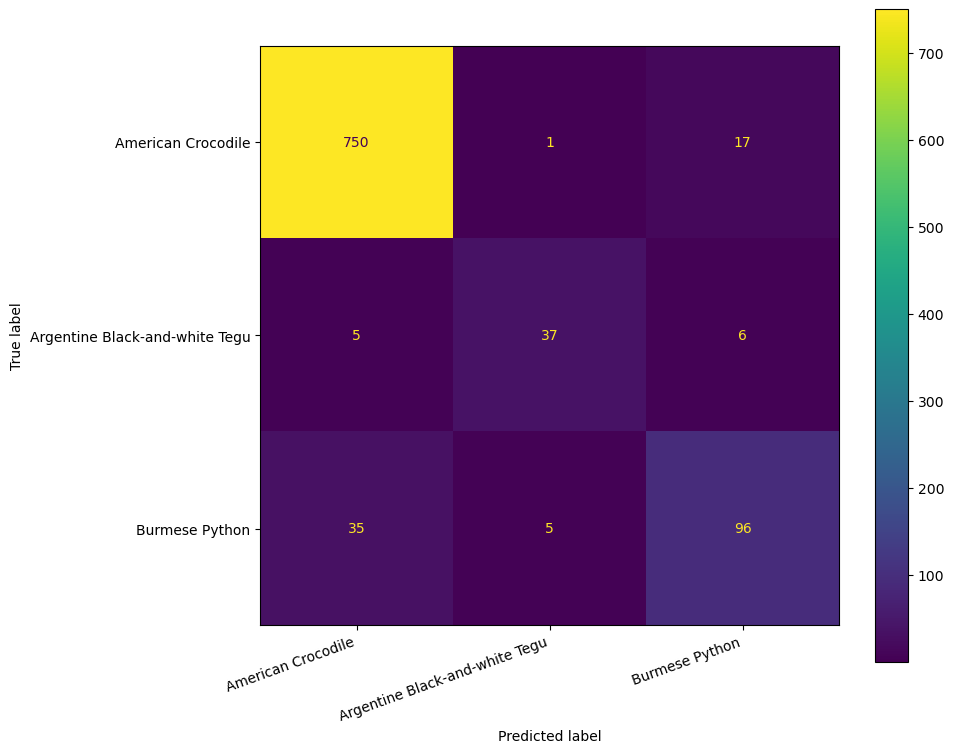

In [55]:
# Create confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

# Create larger figure
fig, ax = plt.subplots(figsize=(10, 8))

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(ax=ax)

# Rotate x-axis labels
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

The Random Forest model correctly classified most observations across all three species. The largest source of error was Burmese Python observations being misclassified as American Crocodiles, while confusion between American Crocodiles and Argentine Black-and-white Tegus was relatively rare.

In [56]:
# View feature importance scores

feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

feature_importance

,feature,importance
0,latitude,0.323404
1,longitude,0.308664
3,month,0.133425
2,year,0.101545
19,place_county_name_Monroe,0.041435
8,place_county_name_Collier,0.029581
18,place_county_name_Miami-Dade,0.018488
6,place_county_name_Broward,0.016027
26,place_county_name_St. Lucie,0.005112
20,place_county_name_Orange,0.004284


Feature importance analysis showed that geographic location was the strongest predictor of species identity, with latitude and longitude accounting for over 63% of total model importance. Temporal variables also contributed meaningful predictive power, particularly month, which supports the seasonal patterns identified during exploratory analysis. County-level indicators provided additional information but were generally less influential than precise geographic coordinates.

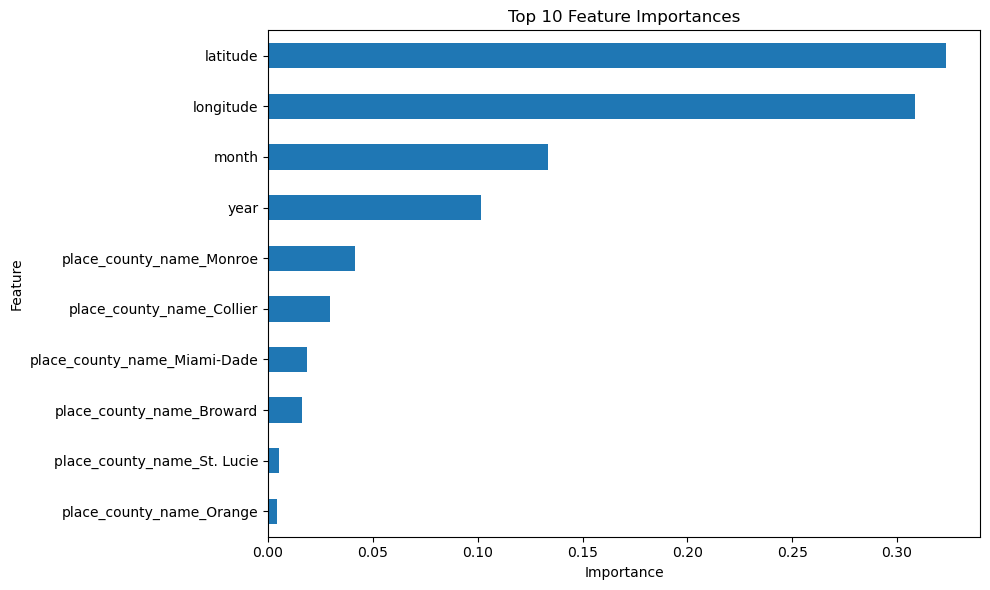

In [57]:
# Plot top 10 feature importances

feature_importance.head(10).sort_values(
    by='importance'
).plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10, 6),
    legend=False
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

Feature importance analysis revealed that geographic location was the strongest predictor of species identity, with latitude (0.323) and longitude (0.309) accounting for over 63% of total importance. Temporal variables also contributed meaningful predictive power, particularly month (0.133), supporting the seasonal patterns identified during exploratory analysis. County-level features had relatively low importance compared to precise geographic coordinates.

### Prediction Confidence

In [58]:
max_probs = pd.Series(
    rf_model.predict_proba(
        X_test_encoded
    ).max(axis=1)
)

max_probs.describe()

count    952.000000
mean       0.904086
std        0.147226
min        0.360000
25%        0.860000
50%        0.980000
75%        1.000000
max        1.000000
dtype: float64

The Random Forest model produced highly confident predictions, with an average prediction confidence of approximately 90% and a median confidence of 98%. High confidence does not necessarily imply correctness, but it suggests the model frequently identified strong patterns in the feature space.

## Model Comparison

In [59]:
# Create Decision Tree model

dt_model = DecisionTreeClassifier(
    random_state=42
)



A Decision Tree classifies observations by repeatedly splitting the data into smaller groups based on feature values. Each split is chosen to maximize separation between species classes. Decision Trees are highly interpretable because predictions can be traced through a sequence of decision rules. However, a single tree is more susceptible to overfitting than ensemble methods such as Random Forest.

In [60]:
# Train model

dt_model.fit(
    X_train_encoded,
    y_train
)

# Make predictions

dt_pred = dt_model.predict(
    X_test_encoded
)

# Evaluate model

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average='macro'
)

print("Accuracy:", dt_accuracy)
print("Macro F1:", dt_f1)

Accuracy: 0.8855042016806722
Macro F1: 0.7781395980580604


In [61]:
# Create Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)



Logistic Regression estimates the probability that an observation belongs to each species class based on a weighted combination of feature values. Unlike tree-based models, Logistic Regression assumes relatively simple relationships between features and target classes. This can limit performance when class boundaries are complex or nonlinear.

In [62]:
# Train model

lr_model.fit(
    X_train_encoded,
    y_train
)

# Make predictions

lr_pred = lr_model.predict(
    X_test_encoded
)

# Evaluate model

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='macro'
)

print("Accuracy:", lr_accuracy)
print("Macro F1:", lr_f1)

Accuracy: 0.8224789915966386
Macro F1: 0.397366974971223


c:\Users\joeyc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [63]:
rf_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        accuracy
    ],
    'Macro F1': [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

model_results.sort_values(
    by='Macro F1',
    ascending=False
)

,Model,Accuracy,Macro F1
2,Random Forest,0.927521,0.842967
1,Decision Tree,0.885504,0.778140
0,Logistic Regression,0.822479,0.397367


Three classification algorithms were evaluated. Random Forest achieved the best overall performance with 92.8% accuracy and a macro F1-score of 0.843. Decision Tree performed reasonably well but was less accurate than Random Forest. Logistic Regression produced substantially lower macro F1 scores, indicating difficulty identifying the minority species classes. These results suggest that species observations are influenced by nonlinear relationships between geographic and temporal variables, making tree-based methods more appropriate for this problem.

## Feature Engineering Experiment: Wet vs Dry Season

Wet Season: May–October
Dry Season: November–April
A wet/dry season feature was engineered based on Florida's seasonal climate patterns and evaluated for its impact on model performance.

In [64]:
# Create wet/dry season feature

model_df_season = model_df.copy()

model_df_season['season'] = np.where(
    model_df_season['month'].between(5, 10),
    'Wet',
    'Dry'
)

In [65]:
# Create new X and y with season feature
X_season = model_df_season[
    [
        'latitude',
        'longitude',
        'place_county_name',
        'year',
        'month',
        'season'
    ]
]

y_season = model_df_season['common_name']

In [66]:
# Split data into training and testing sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_season,
    y_season,
    test_size=0.2,
    random_state=42,
    stratify=y_season
)

In [67]:
# One-hot encode county names and season
X_train_s = pd.get_dummies(
    X_train_s,
    columns=[
        'place_county_name',
        'season'
    ]
)

X_test_s = pd.get_dummies(
    X_test_s,
    columns=[
        'place_county_name',
        'season'
    ]
)

X_test_s = X_test_s.reindex(
    columns=X_train_s.columns,
    fill_value=0
)

In [68]:
rf_season = RandomForestClassifier(
    random_state=42
)

rf_season.fit(
    X_train_s,
    y_train_s
)

season_pred = rf_season.predict(
    X_test_s
)

In [69]:
# Calculate metrics 
season_accuracy = accuracy_score(
    y_test_s,
    season_pred
)

season_f1 = f1_score(
    y_test_s,
    season_pred,
    average='macro'
)

print(season_accuracy)
print(season_f1)

0.9264705882352942
0.8516364954668297


In [70]:
# Compare results with and without season feature
season_comparison = pd.DataFrame({
    'Model': [
        'Random Forest (Baseline)',
        'Random Forest (+ Season)'
    ],
    'Accuracy': [
        0.927521,
        season_accuracy
    ],
    'Macro F1': [
        0.842967,
        season_f1
    ]
})

season_comparison

,Model,Accuracy,Macro F1
0,Random Forest (Baseline),0.927521,0.842967
1,Random Forest (+ Season),0.926471,0.851636


Adding a wet/dry season feature produced a small decrease in overall accuracy but improved the macro F1-score from 0.843 to 0.852. Because macro F1 gives equal weight to each species class, this result suggests that seasonal information may improve classification of the less common species without materially affecting overall predictive performance.

In [71]:
print(
    classification_report(
        y_test_s,
        season_pred
    )
)

                                precision    recall  f1-score   support

            American Crocodile       0.95      0.97      0.96       768
Argentine Black-and-white Tegu       0.93      0.77      0.84        48
                Burmese Python       0.79      0.72      0.75       136

                      accuracy                           0.93       952
                     macro avg       0.89      0.82      0.85       952
                  weighted avg       0.92      0.93      0.92       952



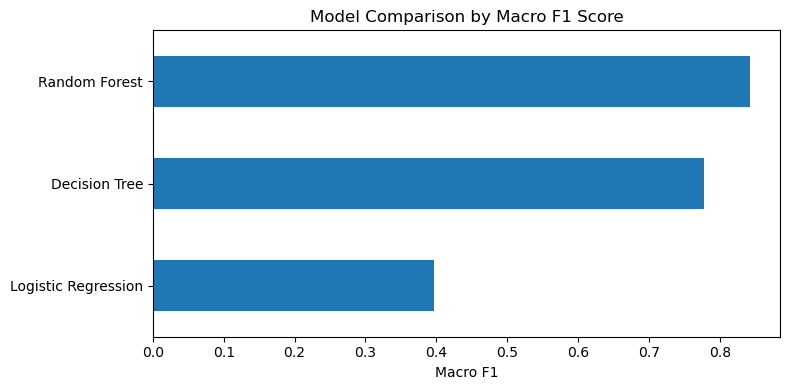

In [72]:
model_results.sort_values(
    by='Macro F1',
    ascending=True
).plot(
    x='Model',
    y='Macro F1',
    kind='barh',
    legend=False,
    figsize=(8, 4)
)

plt.title('Model Comparison by Macro F1 Score')
plt.xlabel('Macro F1')
plt.ylabel('')

plt.tight_layout()
plt.show()

A wet/dry season feature was engineered based on Florida's seasonal climate patterns. While overall accuracy remained largely unchanged (92.8% vs. 92.6%), the macro F1-score improved from 0.843 to 0.852. The improvement was primarily driven by better identification of minority species, particularly Argentine Black-and-white Tegus. These results suggest that broader seasonal patterns provide useful predictive information beyond individual month values alone.

## Conclusion

This project combined SQL, exploratory data analysis, feature engineering, and machine learning to investigate wildlife observation patterns for American Crocodiles, Burmese Pythons, and Argentine Black-and-white Tegus in Florida.

Exploratory analysis revealed clear geographic and seasonal differences among the three species. Observation locations were concentrated in South Florida and tended to cluster in distinct geographic regions. American Crocodiles were observed across the widest geographic area, while Burmese Pythons and Argentine Black-and-white Tegus exhibited more localized distributions. Seasonal patterns were also evident, with each species showing different observation peaks throughout the year.

These findings were reflected in the machine learning results. Feature importance analysis showed that latitude and longitude were the strongest predictors of species identity, accounting for over 63% of total model importance. Month also contributed meaningful predictive power, supporting the seasonal trends identified during exploratory analysis.

Among the models evaluated, Random Forest achieved the strongest overall performance with a macro F1-score of 0.843, outperforming both Decision Tree and Logistic Regression. The superior performance of Random Forest suggests that species observations are influenced by complex, nonlinear relationships between geographic and temporal variables that are better captured by tree-based ensemble methods.

An additional feature engineering experiment introduced a wet/dry season variable based on Florida's seasonal climate patterns. While overall accuracy remained largely unchanged, the macro F1-score improved to 0.852, indicating modest gains in identifying minority species classes.

Overall, the results demonstrate that geographic location and temporal patterns contain meaningful predictive information for wildlife observations. The project also illustrates how citizen science data, relational databases, feature engineering, and machine learning can be combined to generate insights into species distribution patterns and support predictive ecological analysis.


In [ ]:
'''# Export cleaned dataset for Power BI

df.to_csv(
    'data/wildlife_observations.csv',
    index=False
)'''